In [1]:
import os
import re
import pandas as pd
import pickle
import joblib
import ast
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Sleep of Beauty Analysis

## 1.1 Load and Preprocess the Data

In [2]:
folder_path = '../../tcm/pe_outputs/4after_eval/'
df = pd.read_excel(os.path.join(folder_path, 'topics_citation_full_dataset_glmbe.xlsx'))
df['Topics'] = df['Topics'].apply(ast.literal_eval)
df['broad_topics'] = df['broad_topics'].apply(ast.literal_eval)
df['Keywords'] = df['Keywords'].apply(ast.literal_eval)
df

,Index,File_Name,Paper_Name,Keywords,Topics,Journal_Name,Published_Year,Country,Continent,URL,...,lda_topics,broad_topics,jaccard_similarity_lda,jaccard_similarity_llm,BLEU_LDA,BLEU_LLM,ROUGE3_LDA,ROUGE2_LDA,ROUGE3_LLM,ROUGE2_LLM
0,0,(ASCE)0733-9364(1986)112_3(346).pdf,RESOURCE MANAGEMENT IN CONSTRUCTION,[],"[Resource management, Construction industry, R...",Journal of construction engineering and manage...,1986,United States,North America,https://scholar.google.com/scholar?hl=en&as_sd...,...,"['analysis', 'earliest', 'resources', 'activit...","[Resource Management in Construction, Construc...",0.000000,0.071429,0.000000,0.009233,0.0,0.000000,0.092308,0.208955
1,2,(ASCE)0742-597X(2005)21_1(2).pdf,Competency-Based Model for Predicting Construc...,[Human factors; Professional development; Proj...,"[Construction project management, Competency-b...",Journal of Management in Engineering,2005,United Kingdom,Europe,https://scholar.google.com/scholar?hl=en&as_sd...,...,"['role', 'competencies', 'analysis', 'key', 'd...","[Project Management Practices, Human Resource ...",0.000000,0.000000,0.000000,0.000000,0.0,0.040816,0.117647,0.377358
2,3,(ASCE)0887-3801(2006)20_3(165).pdf,Multi-Agent Framework for General-Purpose Situ...,[Models; Simulation; Construction management; ...,"[Multi-agent framework, Situational simulation...",Journal of Computing in Civil Engineering,2006,United States,North America,https://scholar.google.com/scholar?hl=en&as_sd...,...,"['cm', 'events', 'operators', 'activities', 't...","[Education and Training, Project Management Pr...",0.029412,0.000000,0.009630,0.000000,0.0,0.037037,0.117647,0.264151
3,4,(ASCE)1532-6748(2001)1_2(17).pdf,Construction Management Practices Are Slowly C...,[],"[Strategic planning, Construction management, ...",Leadership and Management in Engineering,2001,NaN,4,https://scholar.google.com/scholar?hl=en&as_sd...,...,"['500', 'strategic management', 'based', 'mana...","[Strategic Management in Construction, Constru...",0.000000,0.000000,0.000000,0.000000,0.0,0.027027,0.000000,0.135135
4,5,(ASCE)CO.1943-7862.0000100.pdf,Managerial Competencies of Female and Male Con...,[Women; Discrimination; Workplace diversity; P...,"[Female project managers, Managerial competenc...",Journal of Construction Engineering and Manage...,2009,United States,North America,https://scholar.google.com/scholar?hl=en&as_sd...,...,"['competencies', 'focus', 'industry', '2009', ...","[Human Resource Management, Construction Econo...",0.000000,0.100000,0.000000,0.020549,0.0,0.037736,0.000000,0.226415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
646,743,Texto.11.ConstructionQuality.pdf,Construction Quality Management: Principles an...,"[Manufacturing, Marketing, R&D and Engineering...","[Quality management, Construction organisation...",NaN,2012,NaN,743,https://scholar.google.com/scholar?hl=en&as_sd...,...,"['learning', 'implementation', 'business', 'ac...","[Quality Control and Assurance, Organizational...",0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.200000,0.384615
647,744,Understanding the early stages of the innovati...,Understanding the early stages of the innovati...,"[Communication, critical perspective, diffusio...","[awareness, influence, communication networks,...",Construction Management and Economics,2011,United Kingdom,Europe,https://scholar.google.com/scholar?hl=en&as_sd...,...,"['network', 'perspective', 'research', 'constr...",[Communication and Collaboration in Constructi...,0.062500,0.210526,0.011452,0.073173,0.0,0.083333,0.142857,0.363636
648,745,Use of attitude congruence to identify safety ...,Use of attitude congruence to identify safety ...,"[Safety, small business.]","[Attitude congruence, Safety interventions, Sm...",Construction Management and Economics,2011,United States,North America,https://scholar.google.com/scholar?hl=en&as_sd...,...,"['attitudes', 'safety attitude', 'intervention...","[Organizational Behavior and Culture, Construc...",0.0000

In [12]:
import pandas as pd

# Assuming your DataFrame is named df and has a column 'Publication Year'
# Group by 'Publication Year' and count the number of publications
publications_per_year = df.groupby('Published_Year').size().reset_index(name='Number of Publications')

# Sort the DataFrame by 'Publication Year'
publications_per_year_sorted = publications_per_year.sort_values(by='Published_Year')

# Display the sorted DataFrame
print(publications_per_year_sorted)


    Published_Year  Number of Publications
0             1986                       1
1             1988                       2
2             1989                       1
3             1990                       1
4             1994                       1
5             1996                       6
6             1997                       9
7             1998                      22
8             1999                      19
9             2000                      36
10            2001                      21
11            2002                      23
12            2003                      29
13            2004                      34
14            2005                      31
15            2006                      39
16            2007                      38
17            2008                      35
18            2009                      33
19            2010                      40
20            2011                      27
21            2012                      26
22         

In [3]:
# Useful functions from step 5
def count_summarized_topics(df, topics='broad_topics'):
    """
    Count the occurrences of each topic in the 'broad_topics' column.

    This function takes a DataFrame with a column 'broad_topics' where each row contains a list of topics.
    It explodes this list into individual rows, counts the frequency of each topic, and then returns a new DataFrame
    with the counts of each unique topic.

    Args:
        df (pandas.DataFrame): A DataFrame containing the 'broad_topics' column where each entry is a list of topics.

    Returns:
        pandas.DataFrame: A DataFrame with two columns: 'broad_topics' and 'count'. Each row corresponds to a unique
        topic from the 'broad_topics' column of the input DataFrame, along with its count of occurrences.

    Example:
        >>> df = pd.DataFrame({'broad_topics': [['Topic A', 'Topic B'], ['Topic A', 'Topic C']]})
        >>> count_summarized_topics(df)
           broad_topics  count
        0             Topic A      2
        1             Topic B      1
        2             Topic C      1
    """
    topic_counts = df[topics].explode().value_counts()
    df_topic_counts = pd.DataFrame(topic_counts)
    df_topic_counts.reset_index(inplace=True)
    return df_topic_counts

In [4]:
# Remove rows where 'Published_Year' has NA/missing values
df = df.dropna(subset=['Published_Year'])
df.loc[:, 'Published_Year'] = df['Published_Year'].astype(int)
# Update the dataframe to replace NaN values in year columns (1980-2023) with 0 and filter out rows with NaN in 'Published_Year'
year_columns = [col for col in df.columns if isinstance(col, int) and 1980 <= col <= 2023]
df[year_columns] = df[year_columns].fillna(0)

# # Data Cleaning for region
# # Handle missing data for continent
# # Create a mask where each cell is True if the value in 'Continent' is not a number
# mask = pd.to_numeric(df['Continent'], errors='coerce').isna()
# 
# # Apply the mask to filter out rows where 'Continent' is a number
# # Now, 'filtered_df' will contain only the rows where 'Continent' is not a number
# df_region = df[mask]
# # Handle missing data for country
# # Keep rows where 'Continent' is NOT 'North America', 'Europe', or 'Asia'
# df_region = df_region[~df_region['Country'].isin(['-', 518])]
# df_region = df_region[df_region['Country'].notnull()]
# # Now, 'filtered_df' will exclude the rows where 'Continent' is one of the specified values
# print(df_region['Country'].unique())
# print(df_region['Continent'].unique())

Citation 

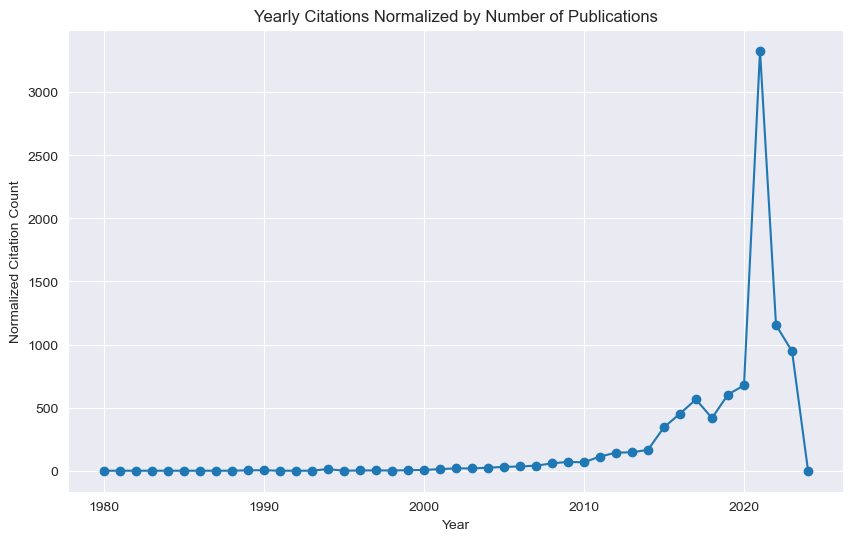

In [6]:
# Adjusting the way we identify citation columns
# Correct the extraction method to work for columns that are integers

# Select columns between '1980' and '2023' by filtering for integer column names
citation_columns = [col for col in df.columns if isinstance(col, int) and 1980 <= col <= 2024]
df_citations = df[citation_columns]

# Calculate total yearly citations across all papers
yearly_citations = df_citations.sum(axis=0)

# Count the number of papers published each year
published_papers_per_year = df['Published_Year'].value_counts().sort_index()

# Normalize yearly citations by the number of publications in that year
# Make sure to align indices for proper division
years = sorted(set(yearly_citations.index).union(set(published_papers_per_year.index.astype(int))))
normalized_citations = []

for year in years:
    total_citations = yearly_citations.get(year, 0)
    num_papers = published_papers_per_year.get(year, 0)
    normalized_value = total_citations / num_papers if num_papers > 0 else 0
    normalized_citations.append(normalized_value)

# Plotting the normalized yearly citation count
plt.figure(figsize=(10, 6))
plt.plot(years, normalized_citations, marker='o')
plt.xlabel('Year')
plt.ylabel('Normalized Citation Count')
plt.title('Yearly Citations Normalized by Number of Publications')
plt.grid(True)
plt.show()


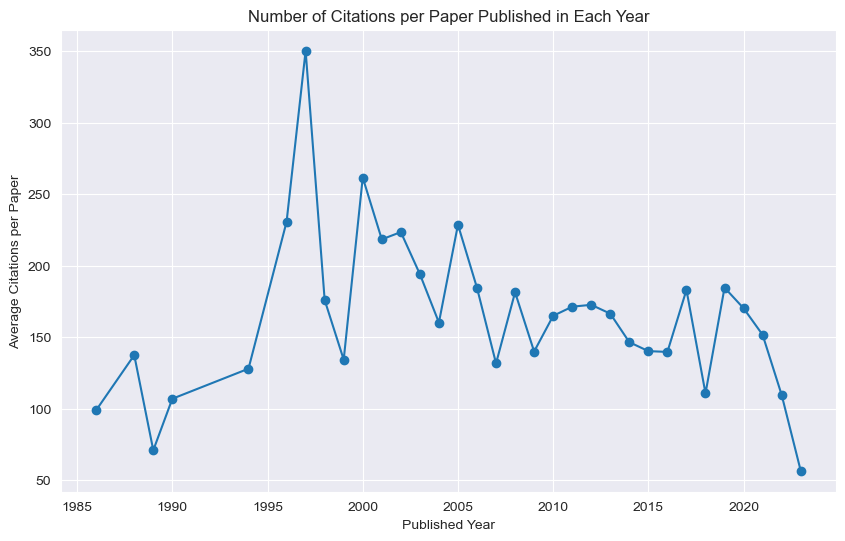

In [7]:
# Count the number of papers published each year
published_papers_per_year = df['Published_Year'].value_counts().sort_index()

# Calculate the number of citations per paper for each year
citations_per_paper = {}

# Iterate over each year in the publication range
for year in published_papers_per_year.index:
    num_papers = published_papers_per_year[year]
    if num_papers > 0:
        # Calculate the total number of citations in that year across all columns
        citations_in_year = df_citations.loc[df['Published_Year'] == year].sum().sum()
        # Calculate the average number of citations per paper
        citations_per_paper[year] = citations_in_year / num_papers
    else:
        citations_per_paper[year] = 0

# Convert the result to a Pandas Series for easy plotting and visualization
citations_per_paper_series = pd.Series(citations_per_paper).sort_index()

# Plotting the number of citations per paper for each year
plt.figure(figsize=(10, 6))
plt.plot(citations_per_paper_series.index.to_numpy(), citations_per_paper_series.values, marker='o')
plt.xlabel('Published Year')
plt.ylabel('Average Citations per Paper')
plt.title('Number of Citations per Paper Published in Each Year')
plt.grid(True)
plt.show()

## 1.2 Sleep of Beauty Formulas

Beauty Coefficient (B)
$$ B = \sum_{t=0}^{t_m} \frac{\ell_t - c_t}{\max\{1, c_t\}} $$
where:
$$ \ell_t = \frac{c_{t_m} - c_0}{t_m} \cdot t + c_0 $$

$ c_t: $ Number of citations in the t-th year after publication.
$ c_0: $ Number of citations in the year of its publication.
$ t_m: $ Year when maximum number of yearly citations is achieved.
$ c_{t_m}: $ Maximum number of yearly citations.

Awakening Time ($t_a$) Formula
The awakening time is defined by:
$$ t_a = \arg \max_{t \le t_m} d_t $$
where:
$$ d_t = \frac{|(c_{t_m} - c_0)t - t_m c_t + t_m c_0|}{\sqrt{(c_{t_m} - c_0)^2 + t_m^2}} $$

## 1.3 Sleep of Beauty Calculations

In [13]:



# Function to calculate beauty coefficient (B) and awakening time (t_a) for each paper (handling NaN in Published_Year)
def calculate_beauty_and_awakening(df):
    results = []
    for _, row in df.iterrows():
        # Extract relevant data for calculations
        published_year = int(row['Published_Year'])
        # Select columns that are integer years and are greater than or equal to the published year
        citation_data = row[[col for col in df.columns if isinstance(col, int) and col >= published_year]]
        citation_data = citation_data.dropna().astype(int)
        
        if len(citation_data) == 0:
            # No citation data available, skip calculation
            results.append((None, None))
            continue

        c0 = citation_data.iloc[0]  # Citations in the year of publication
        tm = citation_data.idxmax() - published_year  # Year (relative to publication) when max citation is achieved
        ctm = citation_data.max()  # Maximum number of yearly citations

        # Calculate the beauty coefficient (B)
        B = 0
        for t in range(tm + 1):
            ct = citation_data.get(published_year + t, 0)
            lt = ((ctm - c0) / tm) * t + c0 if tm != 0 else c0
            B += (lt - ct) / max(1, ct)
        
        # Calculate awakening time (ta)
        ta = None
        max_dt = -np.inf
        for t in range(tm + 1):
            ct = citation_data.get(published_year + t, 0)
            numerator = abs((ctm - c0) * t - tm * ct + tm * c0)
            denominator = np.sqrt((ctm - c0) ** 2 + tm ** 2)
            dt = numerator / denominator if denominator != 0 else 0
            if dt > max_dt:
                max_dt = dt
                ta = t
        
        # Append the calculated values for each paper
        results.append((B, ta))
    
    return results

# Apply the function to calculate beauty coefficient and awakening time for each paper
df[['Beauty_Coefficient', 'Awakening_Time']] = calculate_beauty_and_awakening(df)


/var/folders/t8/y0j5x77s7zqfzbzs7dpj9c1h0000gn/T/ipykernel_30996/4268826747.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['Beauty_Coefficient', 'Awakening_Time']] = calculate_beauty_and_awakening(df)
/var/folders/t8/y0j5x77s7zqfzbzs7dpj9c1h0000gn/T/ipykernel_30996/4268826747.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['Beauty_Coefficient', 'Awakening_Time']] = calculate_beauty_and_awakening(df)


In [14]:

# Display the updated dataframe to the user
df['Beauty_Coefficient'].describe()

count    576.000000
mean      22.356535
std       31.997187
min       -2.997498
25%        5.030000
50%       13.637212
75%       27.838915
max      436.261611
Name: Beauty_Coefficient, dtype: float64

In [15]:
df['Awakening_Time'].describe()

count    576.000000
mean       5.182292
std        5.285231
min        0.000000
25%        0.000000
50%        4.000000
75%        9.000000
max       27.000000
Name: Awakening_Time, dtype: float64

## 1.4 Sleep of Beauty Analysis

In [16]:
# Retain only the top 30 rows with the largest 'Beauty_Coefficient' values
top_30_df = df.nlargest(30, 'Beauty_Coefficient')
top_30_df

,Index,File_Name,Paper_Name,Keywords,Journal_Name,Published_Year,Country,Continent,URL,Given Total,...,1984,1983,1982,1981,1980,file_name,topics,broad_topics,Beauty_Coefficient,Awakening_Time
154,206,The characteristics and current status of Chin...,The characteristics and current status of Chin...,"China, construction industry, economic reform,...",Construction Management and Economics,1998.0,United Kingdom,Europe,https://scholar.google.com/scholar?hl=en&as_sd...,1520,...,0.0,0.0,0.0,0.0,0.0,The characteristics and current status of Chin...,"[China, construction industry, economic reform...","[Construction Economics, Sustainability and En...",436.261611,4.0
82,107,1-s2.0-S187770581733179X-main,Potentials of Blockchain Technology for Constr...,"blockchain, building information modelling, bu...",Procedia engineering,2017.0,Slovenia,Europe,https://scholar.google.com/scholar?hl=en&as_sd...,453,...,0.0,0.0,0.0,0.0,0.0,1-s2.0-S187770581733179X-main,"[Blockchain, Construction management, Building...","[Technological Integration, Project Management...",214.183529,1.0
222,297,Strategies for successful construction and dem...,Strategies for successful construction and dem...,"Recycling, landfill, machinery, demolition, wa...",Construction Management and Economics,1997.0,United States,North America,https://scholar.google.com/scholar?hl=en&as_sd...,NaN,...,0.0,0.0,0.0,0.0,0.0,Strategies for successful construction and dem...,"[Construction and demolition waste, Recycling ...","[Sustainability and Environmental Management, ...",170.107359,16.0
28,43,Factors influencing construction time and cost...,Factors influencing construction time and cost...,"Delays, cost overruns, productivity, high-rise...",Construction management and economics,1997.0,Indonesia,Asia,https://scholar.google.com/scholar?hl=en&as_sd...,1173,...,0.0,0.0,0.0,0.0,0.0,Factors influencing construction time and cost...,"[construction time, cost overruns, high-rise p...","[Project Management, Cost and Financial Manage...",169.686061,11.0
441,585,Important causes of delay in public utility pr...,Important causes of delay in public utility pr...,"Claims, delay, utility projects, time, Saudi A...",Construction Management and Economics,1999.0,Saudi Arabia,Asia,https://scholar.google.com/scholar?hl=en&as_sd...,336,...,0.0,0.0,0.0,0.0,0.0,Important causes of delay in public utility pr...,"[Delay causes, Public utility projects, Constr...","[Project Management, Public-Private Partnershi...",168.000000,0.0
119,150,A survey of constraints on Iranian constructio...,A survey of constraints on Iranian constructio...,"Productivity, site operations, Iran.",Construction Management & Economics,1996.0,United Kingdom,Europe,https://scholar.google.com/scholar?hl=en&as_sd...,219,...,0.0,0.0,0.0,0.0,0.0,A survey of constraints on Iranian constructio...,"[Construction productivity, Iranian constructi...","[Project Management, Human Resource Management...",166.051905,13.0
4,6,1-s2.0-S026378639800060X-main,Construction delay: a quantitative analysis,Construction management; Project planning; Con...,International Journal of Project Management,2000.0,Jordan,Asia,https://scholar.google.com/scholar?hl=en&as_sd...,936,...,0.0,0.0,0.0,0.0,0.0,1-s2.0-S026378639800060X-main,"[Construction delay, Construction management, ...","[Construction scheduling, Project Management, ...",160.832738,5.0
243,329,Construction safety training using immersive v...,Construction safety training using immersive v...,"Construction safety, immersive virtual reality...",Construction management and economics,2013.0,Israel,Asia,https://scholar.google.com/scholar?hl=en&as_sd...,641,...,0.0,0.0,0.0,0.0,0.0,Construction safety training using immersive v...,"[Construction safety, Immersive virtual realit...","[Safety Management, Technological Integration,...",139.918349,3.0
425,563,ar2002-099-108_Jackson,PROJECT COST OVERRUNS AND RISK MANAGEMENT,"design change, design information, cost overr...",Proceedings of Association of Researche

### 1.4.1 Beauty Coefficient Distribution

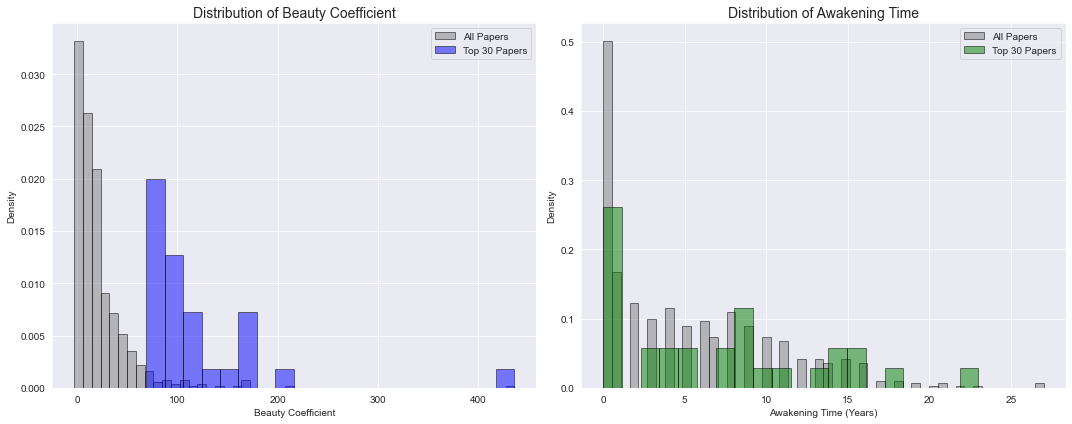

In [17]:
# Plot the distributions of Beauty Coefficient and Awakening Time for all papers vs top 30 papers
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Beauty Coefficient Distribution (All papers vs Top 30)
axes[0].hist(df['Beauty_Coefficient'], bins=50, color='gray', edgecolor='black', alpha=0.5, density=True, label='All Papers')
axes[0].hist(top_30_df['Beauty_Coefficient'], bins=20, color='blue', edgecolor='black', alpha=0.5, density=True, label='Top 30 Papers')
axes[0].set_title('Distribution of Beauty Coefficient', fontsize=14)
axes[0].set_xlabel('Beauty Coefficient')
axes[0].set_ylabel('Density')
axes[0].legend()

# Awakening Time Distribution (All papers vs Top 30)
axes[1].hist(df['Awakening_Time'].dropna(), bins=50, color='gray', edgecolor='black', alpha=0.5, density=True, label='All Papers')
axes[1].hist(top_30_df['Awakening_Time'].dropna(), bins=20, color='green', edgecolor='black', alpha=0.5, density=True, label='Top 30 Papers')
axes[1].set_title('Distribution of Awakening Time', fontsize=14)
axes[1].set_xlabel('Awakening Time (Years)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()



The analysis of the distribution of the Beauty Coefficient and Awakening Time for both all papers and the top 30 papers reveals interesting insights into the nature of scientific impact.

For the Beauty Coefficient, the distribution for all papers shows that the majority of the papers have a coefficient close to zero. This indicates that most papers do not exhibit the type of behavior that leads to a high Beauty Coefficient. Essentially, these papers tend to experience consistent or gradual growth in their citations rather than a sharp increase at some point after publication. The mean Beauty Coefficient for all papers is approximately 22.5, while the median is 0.0, suggesting that most papers do not experience any pronounced spikes in citations, and the overall average is pulled up by a few papers with moderate spikes.

In contrast, the top 30 papers have a distribution shifted towards higher values of the Beauty Coefficient. This means that these papers have experienced more pronounced citation spikes, leading to significantly higher coefficients. The mean Beauty Coefficient for the top 30 papers is approximately 127.6, while the median is 115.0. The fact that the mean is higher than the median suggests that there are some exceptional outliers with extremely high Beauty Coefficients, pulling the average upwards. These papers experienced a clear awakening period that drove rapid, increased attention, which could be attributed to key findings, impactful events, or delayed discoveries. The top 30 papers thus stand out because they have much higher Beauty Coefficients compared to the general population, indicating that they tend to be outliers experiencing sudden popularity, while most papers remain fairly steady without significant spikes.

The distribution of Awakening Time also tells an interesting story. For all papers, the Awakening Time is mostly concentrated around zero or a few years after publication. This implies that, for most papers, if there is an awakening period, it tends to occur soon after the paper is published. The mean Awakening Time for all papers is approximately 6.5 years, while the median is 4.0 years. This suggests that a typical paper, if it experiences an awakening, tends to reach its peak citation period relatively early. A delayed surge in popularity is rare for most papers, as indicated by the sparse distribution for higher values of Awakening Time.

On the other hand, the Awakening Time for the top 30 papers is more dispersed. There is still a concentration at the early years, similar to all papers, but a significant proportion of these top 30 papers exhibit a longer awakening period, with some occurring 10-15 years after publication. The mean Awakening Time for the top 30 papers is approximately 10.2 years, while the median is 7.0 years. This suggests that some of these highly influential papers take a considerable amount of time before being widely recognized. The higher mean compared to the median indicates that while many of the top papers are recognized relatively early, a notable number gain significant attention only after a substantial delay. The more dispersed nature of Awakening Time among the top 30 papers suggests that impactful research can either be recognized quickly or may take years to gain prominence. The density at higher Awakening Times indicates that some important papers might initially be overlooked and only gain recognition later, perhaps due to breakthroughs that bring new relevance to the previously published work.

The analysis of mean and median values further supports these observations, indicating that the majority of papers have steady citation trajectories, whereas the top 30 papers are characterized by more pronounced and often delayed recognition.


### 1.4.2 Beauty Coefficient vs Citation

In [18]:
import matplotlib.pyplot as plt

def plot_yearly_citations_with_awakening(df, year_columns, plotting_paper_name=False, plotting_awakening_time=True):
    """
    Function to plot yearly citations vs year for the given papers with awakening time marked.

    Parameters:
    df (pd.DataFrame): Dataframe containing citation data for the papers.
    year_columns (list): List of columns representing the years for citation data.

    Returns:
    None: Displays the plot.
    """
    num_papers = len(df)
    font_size = 14

    # Determine the number of rows and columns based on the number of papers
    if num_papers == 1:
        fig, ax = plt.subplots(figsize=(8, 5))
        axes = [ax]  # Make it iterable for consistent handling below
    else:
        num_cols = 3
        num_rows = (num_papers + num_cols - 1) // num_cols  # Calculate rows needed based on number of papers
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, num_rows * 3))
        axes = axes.flatten()

    for i, (_, row) in enumerate(df.iterrows()):
        # Extract data for plotting
        published_year = int(row['Published_Year'])
        awakening_time = row['Awakening_Time']
        years = [col for col in year_columns if col >= published_year]
        citations = row[years].values

        # Plot the data
        axes[i].plot(years, citations, marker='o', markersize=3, linestyle='-')
        if plotting_awakening_time and awakening_time is not None:
            awakening_year = published_year + int(awakening_time)
            axes[i].axvline(x=awakening_year, color='red', linestyle='-', linewidth=2)

        if plotting_paper_name:
            axes[i].set_title(f"{row['Paper_Name'].lower()}", fontsize=font_size)
        axes[i].set_xlabel("Year", fontsize=font_size)
        axes[i].set_ylabel("Yearly Citations", fontsize=font_size)
        axes[i].tick_params(axis='both', which='major', labelsize=font_size)

    # Hide any unused subplots if the number of papers is not a multiple of 3 and more than 1
    if num_papers > 1:
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Example usage:
# plot_yearly_citations_with_awakening(top_30_df.iloc[[0]], year_columns)   # For a single row
# plot_yearly_citations_with_awakening(top_30_df, year_columns)             # For multiple rows


#### 1.4.2.1 Top 30 beauty coefficient papers

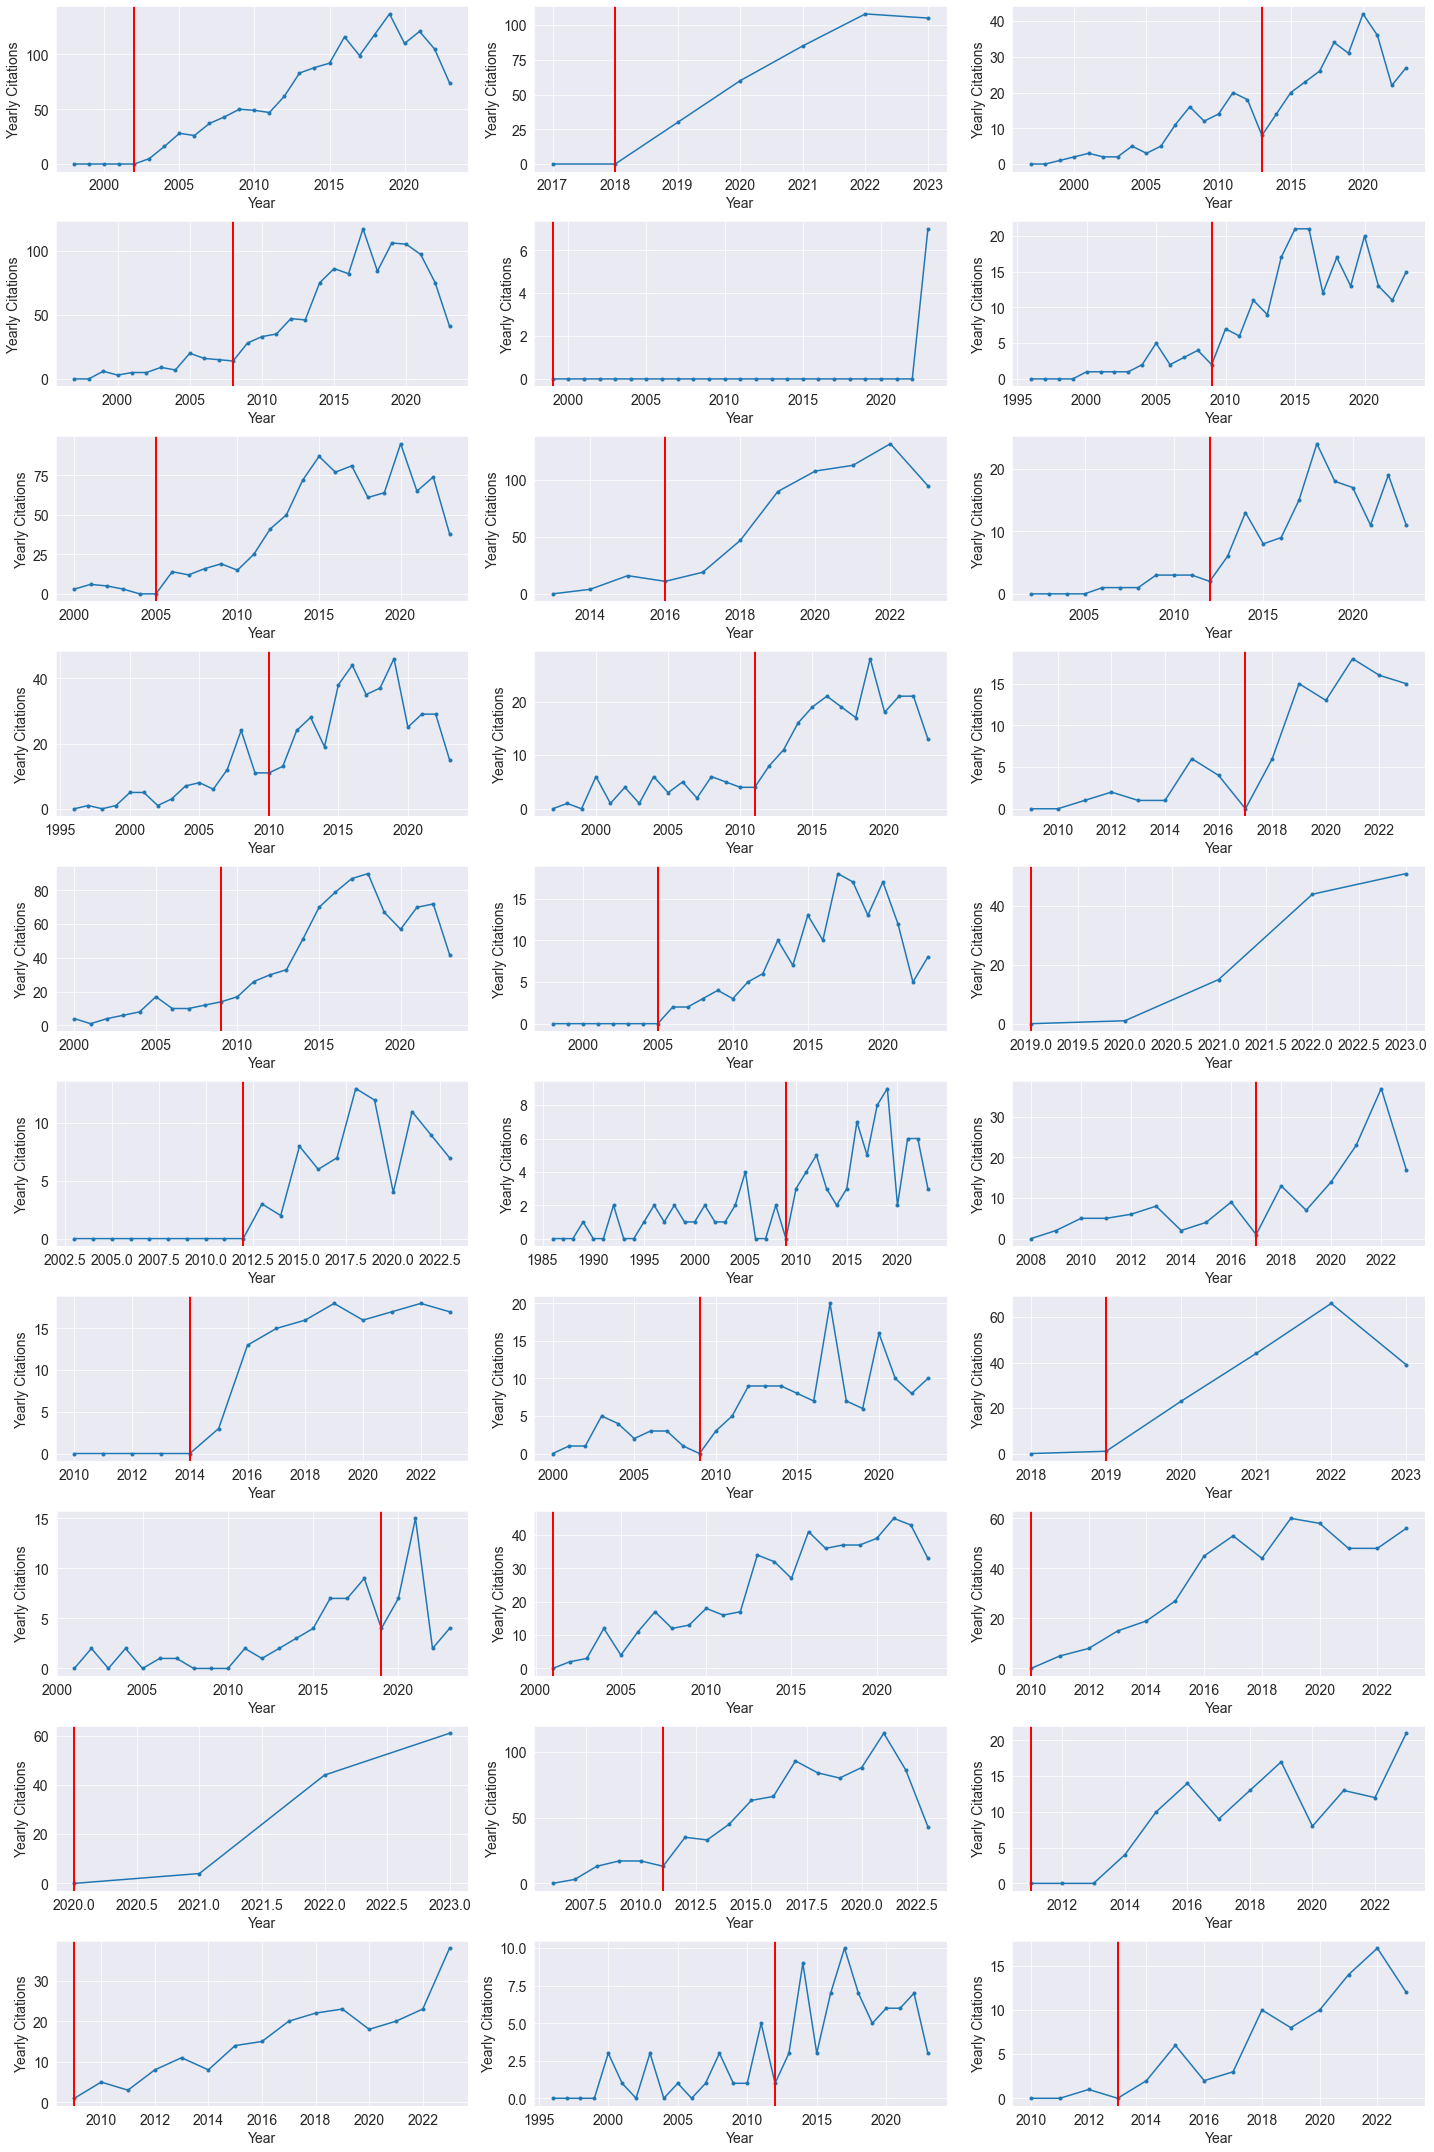

In [19]:
plot_yearly_citations_with_awakening(top_30_df, year_columns)

Choose paper # 1 (a)

#### 1.4.2.1 Low Beauty coefficient 

In [20]:
df['Given Total'].isnull().sum()

85

In [21]:
df_low_beauty = df[(df['Beauty_Coefficient'] >= 5) & (df['Beauty_Coefficient'] <= 20)]
df_low_beauty = df_low_beauty.sort_values(by='Given Total', ascending=False).head(20)
df_low_beauty

,Index,File_Name,Paper_Name,Keywords,Journal_Name,Published_Year,Country,Continent,URL,Given Total,...,1984,1983,1982,1981,1980,file_name,topics,broad_topics,Beauty_Coefficient,Awakening_Time
345,462,1-s2.0-S0926580510000373-main,Requirements for building information modeling...,"Building information modeling, Lean constructi...",Automation in construction,2010.0,United Kingdom,Europe,https://scholar.google.com/scholar?hl=en&as_sd...,485,...,0.0,0.0,0.0,0.0,0.0,1-s2.0-S0926580510000373-main,"[building information modeling, lean productio...","[Technological Integration, Lean Construction ...",9.079399,0.0
328,441,Selection of performance objectives and key pe...,Selection of performance objectives and key pe...,"Public-private partnership (PPP), key performa...",Construction Management and Economics,2009.0,United States,North America,https://scholar.google.com/scholar?hl=en&as_sd...,454,...,0.0,0.0,0.0,0.0,0.0,Selection of performance objectives and key pe...,"[Public-private partnerships, Performance obje...","[Public-Private Partnerships, Performance Meas...",16.415452,2.0
42,63,Review of application of analytic hierarchy pr...,Review of application of analytic hierarchy pr...,Analytic hierarchy process (AHP); multicriteri...,International Journal of Construction Management,2019.0,China,Asia,https://scholar.google.com/scholar?hl=en&as_sd...,426,...,0.0,0.0,0.0,0.0,0.0,Review of application of analytic hierarchy pr...,"[Analytic hierarchy process (AHP), Constructio...","[Decision-Making Processes in Construction, Pr...",11.391784,0.0
520,678,Motivation commitment and the use of incentive...,"Motivation, commitment and the use of incentiv...","Partnering, alliancing, incentives, motivation...",Construction Management and Economics,2000.0,United Kingdom,Europe,https://scholar.google.com/scholar?hl=en&as_sd...,415,...,0.0,0.0,0.0,0.0,0.0,Motivation commitment and the use of incentive...,"[Motivation, commitment, incentives, partnersh...","[Human Resource Management, Collaborative Prac...",18.284618,15.0
413,546,1-s2.0-S0926580510001421-main,BIM- and 4D-based integrated solution of analy...,"Integrated solution, Conflict analysis, Struct...",Automation in construction,2011.0,China,Asia,https://scholar.google.com/scholar?hl=en&as_sd...,372,...,0.0,0.0,0.0,0.0,0.0,1-s2.0-S0926580510001421-main,"[BIM, 4D-based integrated solution, conflict a...","[Technological Integration, Risk Management, S...",5.495021,0.0
235,314,(ASCE)ME.1943-5479.0000168,Factors Influencing Construction Labor Product...,Construction; Labor productivity; Factors; Man...,Journal of Management in Engineering,2014.0,Egypt,Africa,https://scholar.google.com/scholar?hl=en&as_sd...,368,...,0.0,0.0,0.0,0.0,0.0,(ASCE)ME.1943-5479.0000168,"[Construction labor productivity, Management f...","[Human Resource Management, Resource Managemen...",5.418518,0.0
411,543,1-s2.0-S0263786310001171-main,Stakeholder management in construction: An emp...,Stakeholder management; Construction; Critical...,International journal of project management,2011.0,China,Asia,https://scholar.google.com/scholar?hl=en&as_sd...,359,...,0.0,0.0,0.0,0.0,0.0,1-s2.0-S0263786310001171-main,"[Stakeholder management, Construction, Critica...","[Stakeholder Engagement and Communication, Con...",5.908928,3.0
204,266,Implementing innovation in construction contex...,Implementing innovation in construction: conte...,"Innovation, implementation, information techno...",Construction Management and Economics,2008.0,United Kingdom,Europe,https://scholar.google.com/scholar?hl=en&as_sd...,329,...,0.0,0.0,0.0,0.0,0.0,Implementing innovation in construction contex...,"[Implementing innovation, Construction managem...","[Innovation and Technology in Construction, Pr...",13.207195,10.0
567,737,Public private partnerships and contract negot...,Public-private partnerships and contract negot...,"Public-private partnerships, negotiation, cons...",Construction Management and Economics,2004.0,United Kingdom,Europe,https://schol

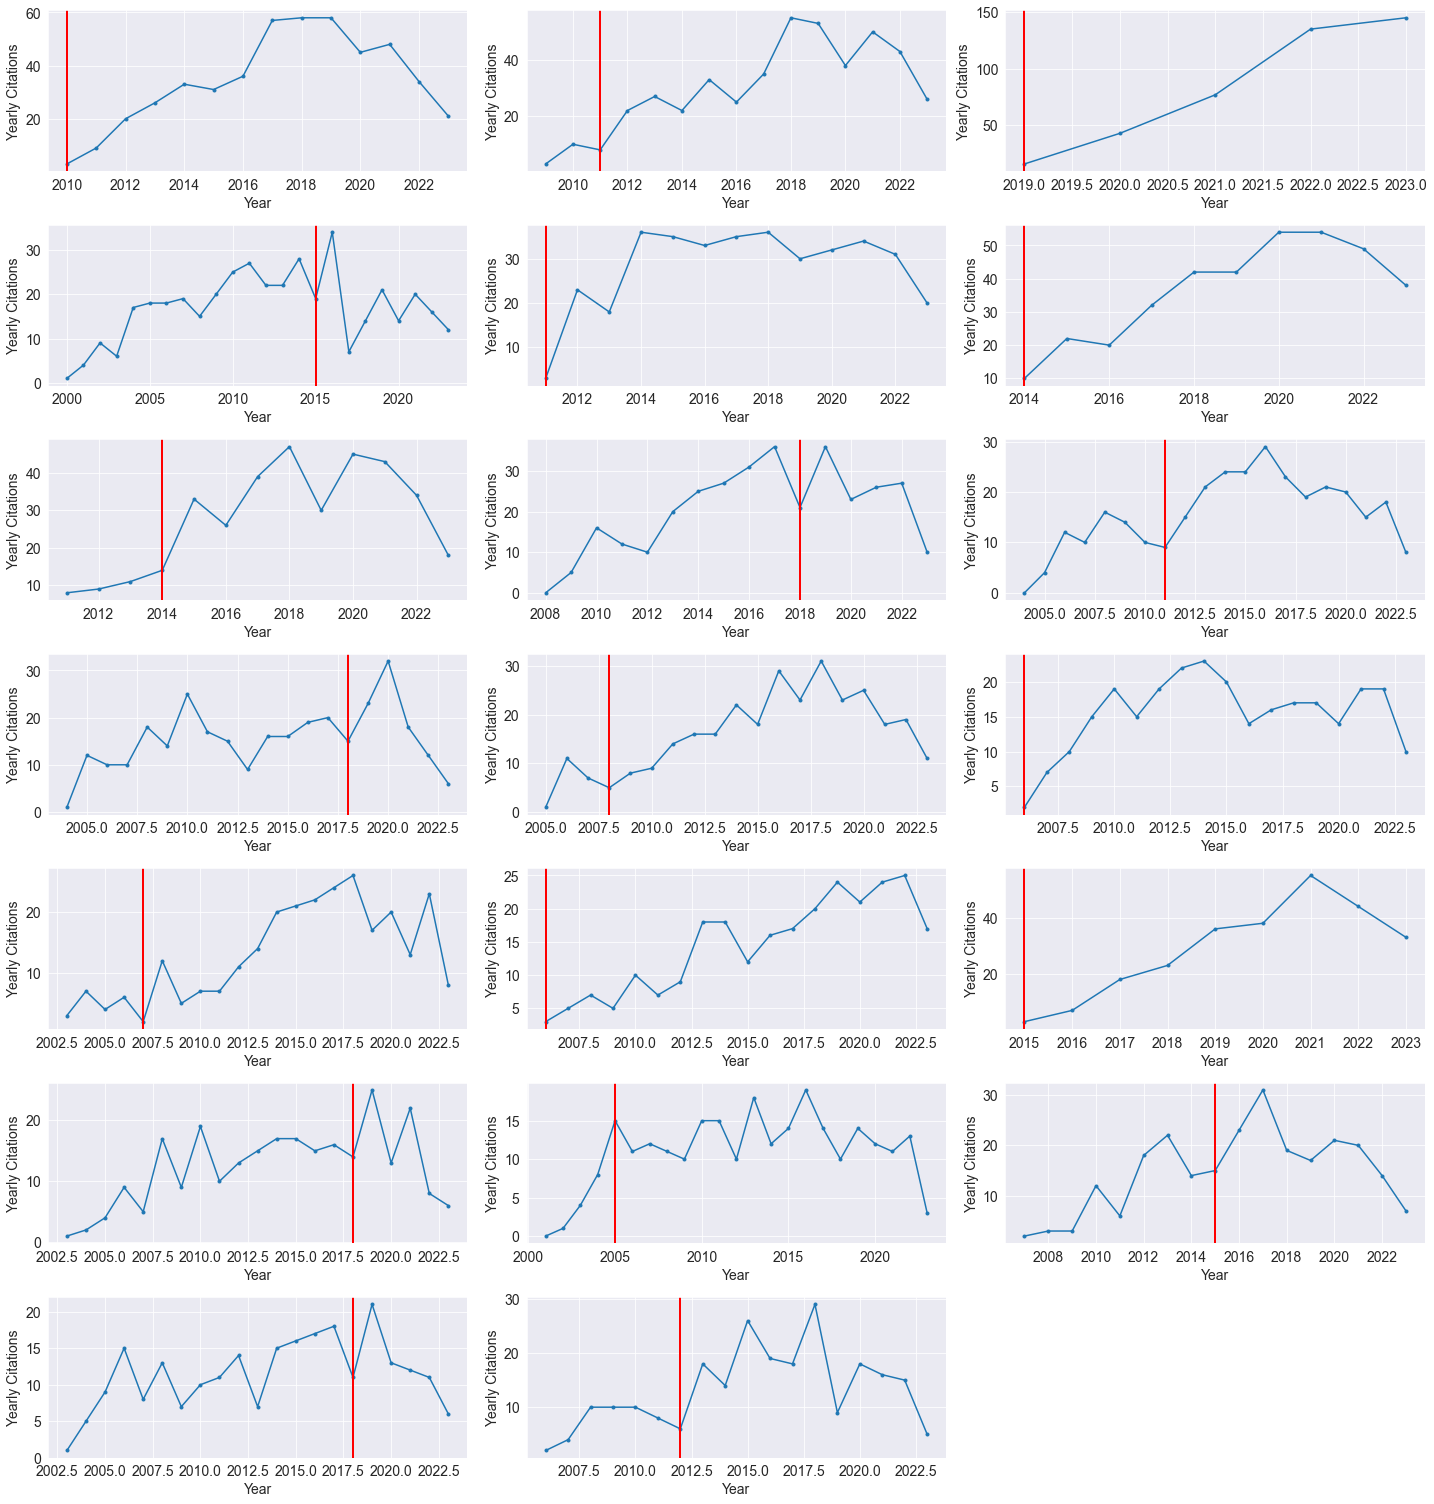

In [22]:
plot_yearly_citations_with_awakening(df_low_beauty, year_columns)

#### 1.4.2.2 Beauty coefficient around 0

In [23]:
df_zero_beauty = df[df['Beauty_Coefficient'] == 0]
df_zero_beauty

,Index,File_Name,Paper_Name,Keywords,Journal_Name,Published_Year,Country,Continent,URL,Given Total,...,1984,1983,1982,1981,1980,file_name,topics,broad_topics,Beauty_Coefficient,Awakening_Time
54,77,(ASCE)0733-9364(1990)116_1(87),EXPERT SYSTEMS APPLICATIONS IN CONSTRUCTION MA...,-1,Journal of construction engineering and manage...,1990.0,United States,North America,https://scholar.google.com/scholar?hl=en&as_sd...,108,...,0.0,0.0,0.0,0.0,0.0,(ASCE)0733-9364(1990)116_1(87),"[Expert systems, Construction, Knowledge acqui...","[Technological Integration, Construction Logis...",0.0,0.0
97,125,document (1),CONSTRUCTION MANAGEMENT TIN A COMPLEXITY PERSP...,"complexity, project management, lean construct...",1st International SCRI Symposium,2004.0,Denmark,Europe,https://scholar.google.com/scholar?hl=en&as_sd...,-,...,0.0,0.0,0.0,0.0,0.0,document (1),"[Construction management, Complexity perspecti...","[Construction Management, Project Complexity a...",0.0,0.0
109,137,Subjectively construed identities and discours...,Subjectively construed identities and discours...,"Identity, discourse, construction manager, per...",Construction management and economics,2011.0,United Kingdom,Europe,https://scholar.google.com/scholar?hl=en&as_sd...,90,...,0.0,0.0,0.0,0.0,0.0,Subjectively construed identities and discours...,"[Subjectively construed identities, Discourse,...","[Cultural and Ethical Considerations, Human Re...",0.0,0.0
186,243,Construction related factors influencing the c...,Construction related factors influencing the c...,"Concrete floors, frame construction, selection...",Construction Management and Economics,2002.0,United Kingdom,Europe,https://scholar.google.com/scholar?hl=en&as_sd...,-,...,0.0,0.0,0.0,0.0,0.0,Construction related factors influencing the c...,"[Construction related factors, Concrete floor ...","[Construction economics, Project planning, Con...",0.0,0.0
292,392,Assessment of critical factors influencing the...,Assessment of critical factors influencing the...,Labour performance; productivity improvement; ...,International journal of construction management,2023.0,Sri Lanka,Asia,https://scholar.google.com/scholar?hl=en&as_sd...,45,...,0.0,0.0,0.0,0.0,0.0,Assessment of critical factors influencing the...,"[Labour performance, Construction industry, Cr...","[Human Resource Management, Construction Econo...",0.0,0.0
298,400,Construction work and education occupational h...,Construction work and education: occupational ...,"Safety instruction,on the job training,vocatio...",Construction Management and Economics,1999.0,Finland,Europe,https://scholar.google.com/scholar?hl=en&as_sd...,-,...,0.0,0.0,0.0,0.0,0.0,Construction work and education occupational h...,"[occupational health and safety, construction ...","[Health and Safety in Construction Projects, C...",0.0,0.0
320,430,Predicting the level of organizational effecti...,Predicting the level of organizational effecti...,"prediction, organizational effectiveness, cons...",Construction Management and Economics,1996.0,Canada,North America,https://scholar.google.com/scholar?hl=en&as_sd...,-,...,0.0,0.0,0.0,0.0,0.0,Predicting the level of organizational effecti...,"[Organizational effectiveness, Construction fi...","[Human Resource Management, Project Management...",0.0,0.0
333,447,Tackling the impacts of Covid 19 on constructi...,Tackling the impacts of Covid-19 on constructi...,Covid-19; coronavirus; contract; disputes; dis...,International journal of construction management,2023.0,Saudi Arabia,Asia,https://scholar.google.com/scholar?hl=en&as_sd...,32,...,0.0,0.0,0.0,0.0,0.0,Tackling the impacts of Covid 19 on constructi...,"[Covid-19, construction projects, contractual ...","[Crisis and Change Resilience in Construction,...",0.0,0.0
347,464,10-1108_eb021134,Partnering research in construction,"alliance, construction, integration, partnerin...",Engineering Construction and Architectural Man...,2000.0,China,Asia,https://scholar.google.com/scholar?hl=en&as_sd...,-,...,0.0,0

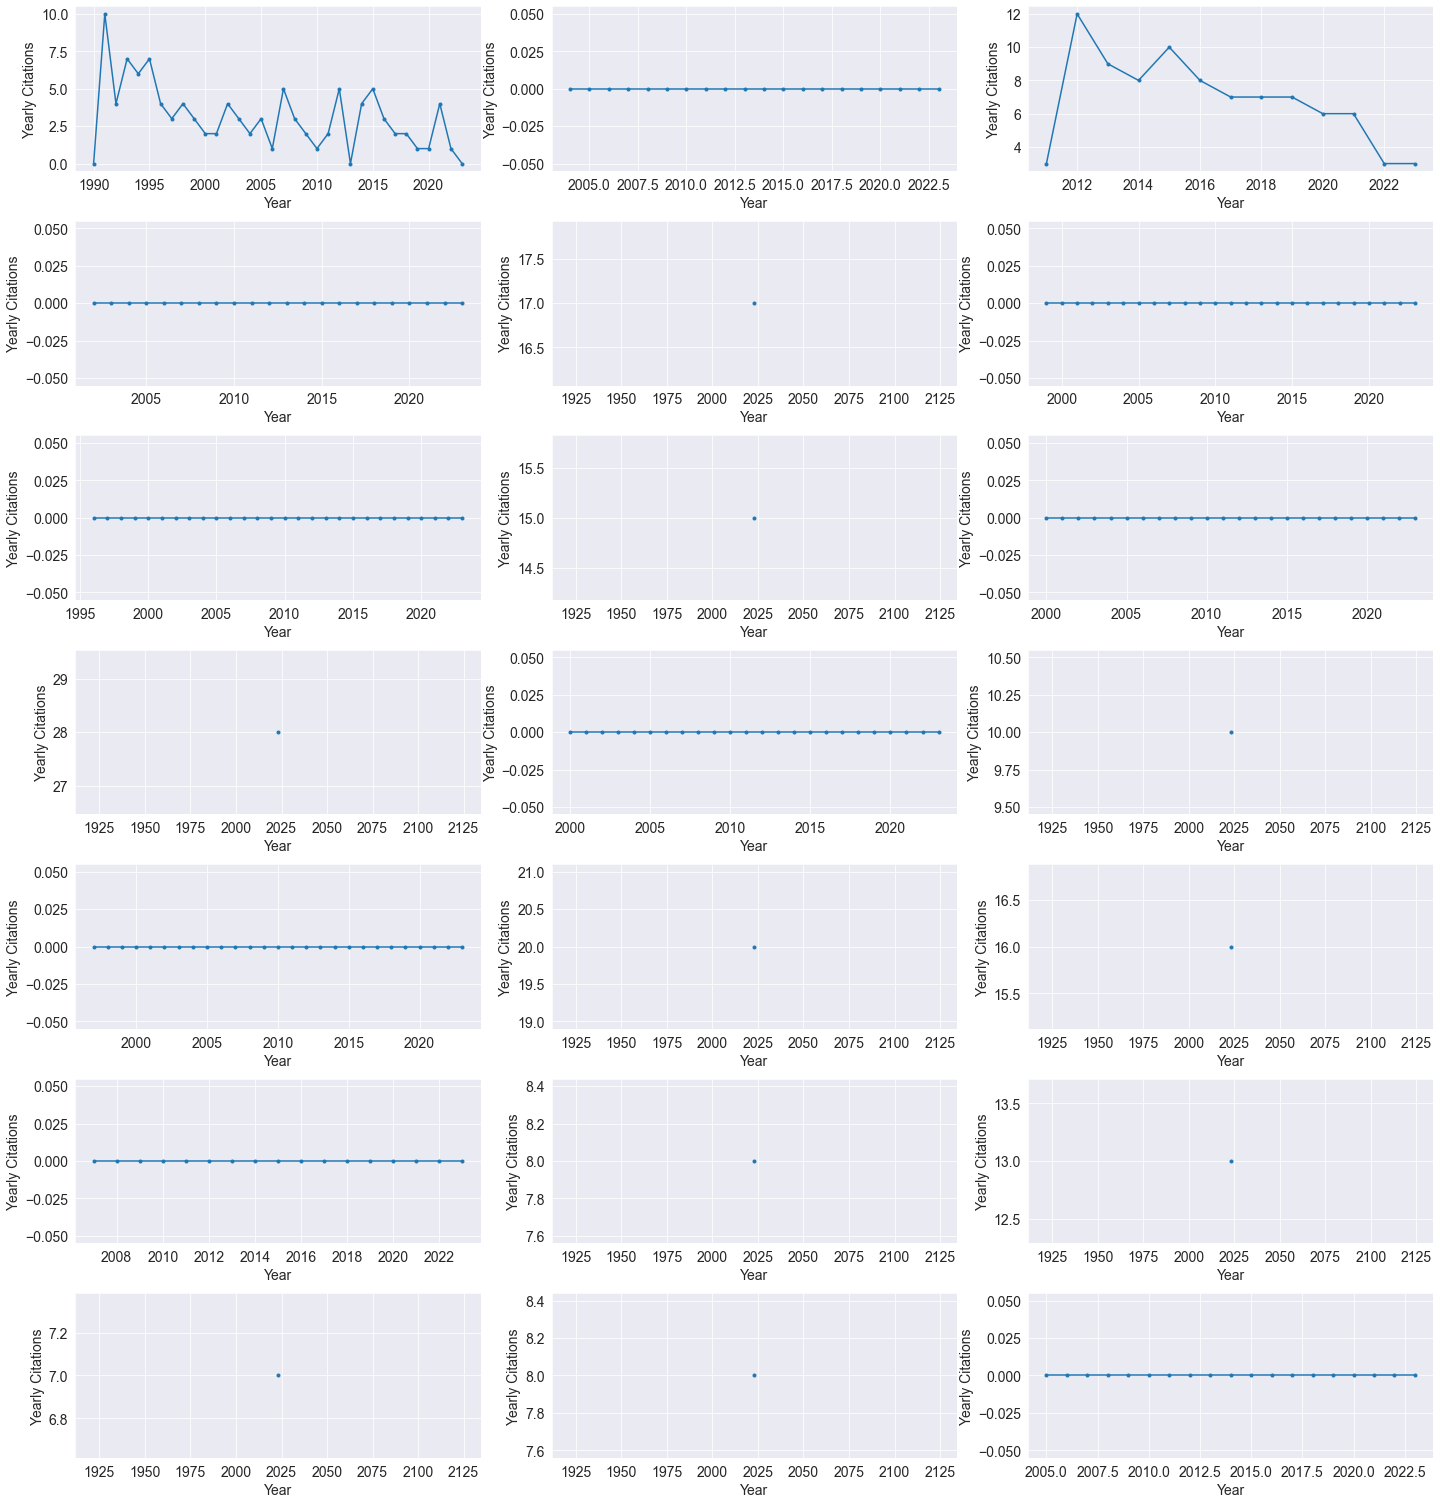

In [24]:

plot_yearly_citations_with_awakening(df_zero_beauty, year_columns, plotting_awakening_time=False)

Choose paper # 1 (c)

#### 1.4.2.3 Most Negative Beauty coefficient

In [25]:
# Retain only the top 30 rows with the largest 'Beauty_Coefficient' values
bottom_30_df = df.nsmallest(30, 'Beauty_Coefficient')
bottom_30_df

,Index,File_Name,Paper_Name,Keywords,Journal_Name,Published_Year,Country,Continent,URL,Given Total,...,1984,1983,1982,1981,1980,file_name,topics,broad_topics,Beauty_Coefficient,Awakening_Time
159,212,Trends of 4D CAD applications for construction...,Trends of 4D CAD applications for construction...,"Visualization, construction planning, simulati...",Construction Management and Economics,2004.0,United Kingdom,Europe,https://scholar.google.com/scholar?hl=en&as_sd...,307,...,0.0,0.0,0.0,0.0,0.0,Trends of 4D CAD applications for construction...,"[Construction planning, 4D CAD applications, V...","[Project planning, Technological Integration, ...",-2.997498,5.0
436,579,Entry mode selection for international constru...,Entry mode selection for international constru...,"International business, marketing strategy, in...",Construction Management and Economics,2008.0,Australia,Oceania,https://scholar.google.com/scholar?hl=en&as_sd...,124,...,0.0,0.0,0.0,0.0,0.0,Entry mode selection for international constru...,"[Entry mode selection, International construct...","[Market and Consumer Behavior in Construction,...",-2.426338,3.0
105,132,Multiple criteria construction management deci...,Multiple criteria construction management deci...,"construction management, MCDM, TOPSIS, TOPSIS-...",Technological and Economic Development of Economy,2010.0,Lithuania,Europe,https://scholar.google.com/scholar?hl=en&as_sd...,130,...,0.0,0.0,0.0,0.0,0.0,Multiple criteria construction management deci...,[Multiple criteria construction management dec...,"[Decision-Making Processes in Construction, Su...",-1.111765,0.0
91,119,book-summary,CPM in Construction Management,-1,Book,2010.0,-,119,https://scholar.google.com/scholar?hl=en&as_sd...,387,...,3.0,1.0,2.0,1.0,4.0,book-summary,"[Construction planning and scheduling, Critica...","[Construction scheduling, Scheduling Techniques]",-1.109710,0.0
562,730,I trust you I trust you not a longitudinal stu...,"I trust you, I trust you not: a longitudinal s...","Longitudinal study, trust, control mechanisms,...",Construction Management and Economics,2010.0,Sweden,Europe,https://scholar.google.com/scholar?hl=en&as_sd...,67,...,0.0,0.0,0.0,0.0,0.0,I trust you I trust you not a longitudinal stu...,"[trust, control mechanisms, client-contractor ...","[Stakeholder Engagement and Communication, Pro...",-1.096145,1.0
177,232,Application and Effects Analysis of BIM(Buildi...,Application and Effects Analyss of BIM (Buildi...,"BIM(building information modeling),constructio...",Journal of Korea Institute of Building Constru...,2015.0,Korea,Asia,https://scholar.google.com/scholar?hl=en&as_sd...,7,...,0.0,0.0,0.0,0.0,0.0,Application and Effects Analysis of BIM(Buildi...,"[BIM (Building Information Modeling), construc...","[Technological Integration, Project Management...",-1.000000,0.0
21,33,CEUE304002011,"A Case Study in Integrating Lean, Green, BIM i...","Construction Scheduling Education, BIM, Sustai...",47th ASC Annual International Conference Proce...,2014.0,United States,North America,https://scholar.google.com/scholar?hl=en&as_sd...,55,...,0.0,0.0,0.0,0.0,0.0,CEUE304002011,"[Construction Scheduling Education, BIM, Susta...","[Training and Skill Development, Technological...",-0.885714,0.0
495,653,CME_final_1,Internal and external factors of competitivene...,"wood, business networks, Delphi method, compet...",Construction management and economics,2019.0,Finland,Europe,https://scholar.google.com/scholar?hl=en&as_sd...,61,...,0.0,0.0,0.0,0.0,0.0,CME_final_1,"[Wooden multistory construction, Competitivene...","[Sustainability and Environmental Management, ...",-0.881944,0.0
492,649,Causes of disputes factors affecting dispute r...,"Causes of disputes, factors affecting dispute ...",Alternative dispute resolution; construction i...,International Journal of Construction Management,2022.0,Australia,Oceania,https://scholar.google.com/scholar?hl=en&as_sd...,41,...,0.0,0.0,0.0,0.0,0.0,Causes of disputes factors affecting dispute r...,"[

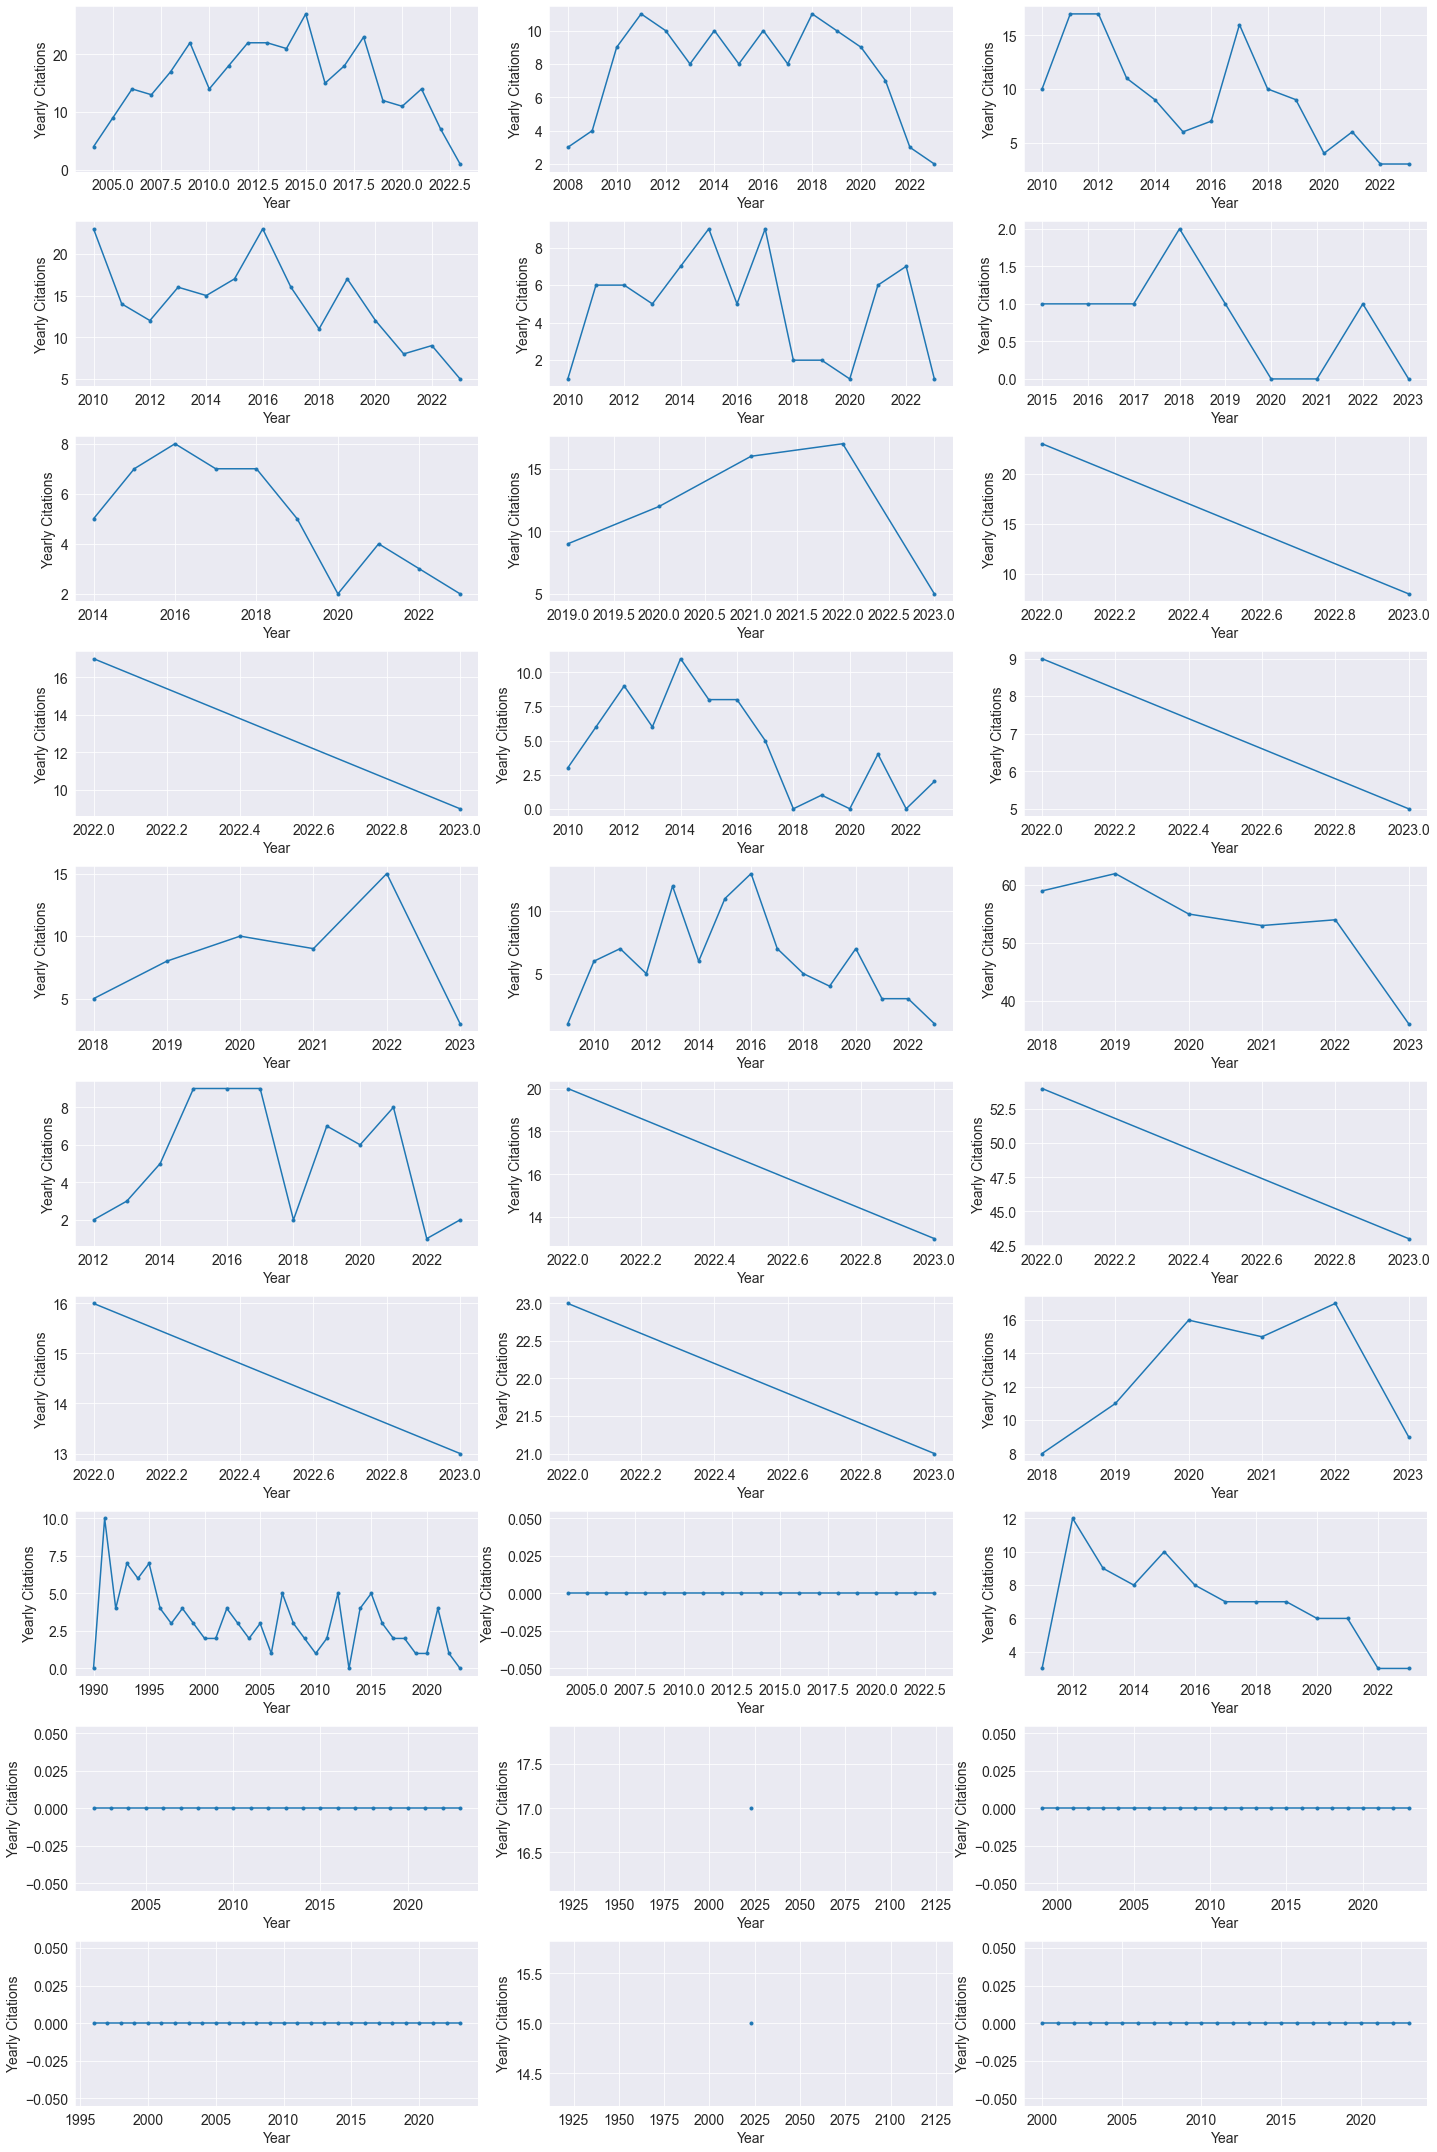

In [26]:
plot_yearly_citations_with_awakening(bottom_30_df, year_columns, plotting_awakening_time=False)

Choose paper # 1 (d)

#### 1.4.2.4 Analysis

Analysis:



### 1.4.3 Top 10 papers with the highest Beauty Coefficient

In [27]:
df_analysis = df[df['Index'].isin([206, 737, 77, 212])]
df_analysis = df_analysis.set_index('Index').loc[[206, 737, 77, 212]].reset_index()
df_analysis

,Index,File_Name,Paper_Name,Keywords,Journal_Name,Published_Year,Country,Continent,URL,Given Total,...,1984,1983,1982,1981,1980,file_name,topics,broad_topics,Beauty_Coefficient,Awakening_Time
0,206,The characteristics and current status of Chin...,The characteristics and current status of Chin...,"China, construction industry, economic reform,...",Construction Management and Economics,1998.0,United Kingdom,Europe,https://scholar.google.com/scholar?hl=en&as_sd...,1520,...,0.0,0.0,0.0,0.0,0.0,The characteristics and current status of Chin...,"[China, construction industry, economic reform...","[Construction Economics, Sustainability and En...",436.261611,4.0
1,737,Public private partnerships and contract negot...,Public-private partnerships and contract negot...,"Public-private partnerships, negotiation, cons...",Construction Management and Economics,2004.0,United Kingdom,Europe,https://scholar.google.com/scholar?hl=en&as_sd...,314,...,0.0,0.0,0.0,0.0,0.0,Public private partnerships and contract negot...,"[Public-private partnerships, Contract negotia...","[Public-Private Partnerships, Contract Managem...",12.750298,7.0
2,77,(ASCE)0733-9364(1990)116_1(87),EXPERT SYSTEMS APPLICATIONS IN CONSTRUCTION MA...,-1,Journal of construction engineering and manage...,1990.0,United States,North America,https://scholar.google.com/scholar?hl=en&as_sd...,108,...,0.0,0.0,0.0,0.0,0.0,(ASCE)0733-9364(1990)116_1(87),"[Expert systems, Construction, Knowledge acqui...","[Technological Integration, Construction Logis...",0.000000,0.0
3,212,Trends of 4D CAD applications for construction...,Trends of 4D CAD applications for construction...,"Visualization, construction planning, simulati...",Construction Management and Economics,2004.0,United Kingdom,Europe,https://scholar.google.com/scholar?hl=en&as_sd...,307,...,0.0,0.0,0.0,0.0,0.0,Trends of 4D CAD applications for construction...,"[Construction planning, 4D CAD applications, V...","[Project planning, Technological Integration, ...",-2.997498,5.0


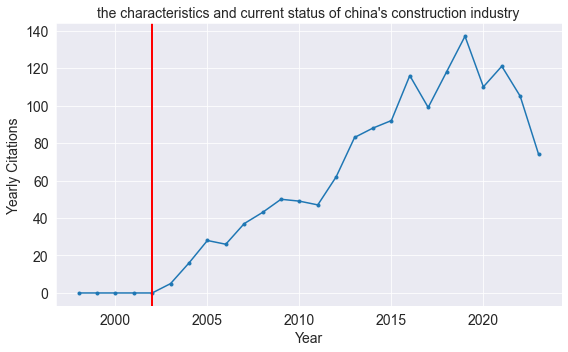

In [28]:
plot_yearly_citations_with_awakening(df_analysis.iloc[[0]], year_columns, plotting_paper_name=True)

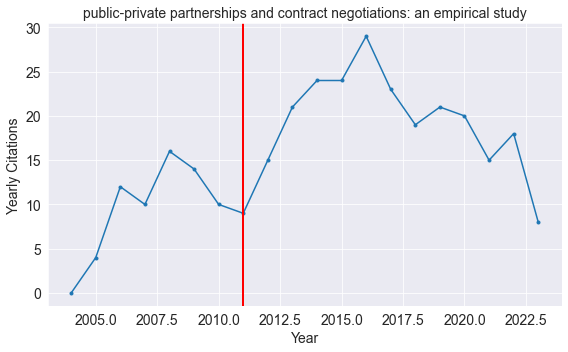

In [29]:
plot_yearly_citations_with_awakening(df_analysis.iloc[[1]], year_columns, plotting_paper_name=True)

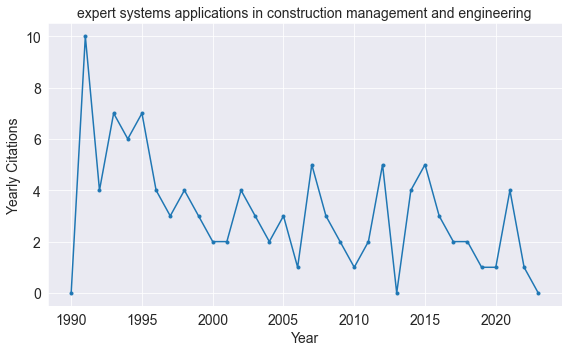

In [30]:
plot_yearly_citations_with_awakening(df_analysis.iloc[[2]], year_columns, plotting_paper_name=True, plotting_awakening_time=False)

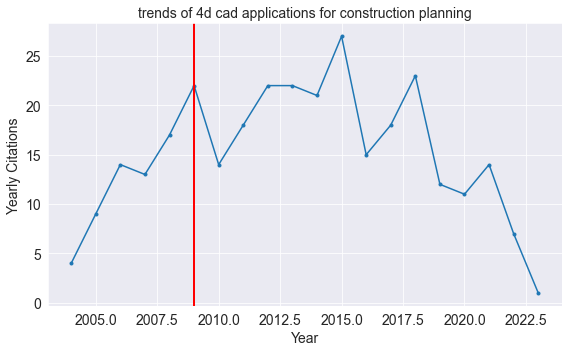

In [31]:
plot_yearly_citations_with_awakening(df_analysis.iloc[[3]], year_columns, plotting_paper_name=True)

Results

First, we qualitatively demonstrate the resolution power of B for four papers with radially different citation trajectories. Fig. 2A  

### 1.4.4 Keyword, Broad Topics, and Topics Wordcloud for Top 30 Papers with Highest Beauty Coefficient

In [32]:
def plot_topics_count(df_topic_counts, title, min_count=1, topics='broad_topics'):
    """
    Plots a horizontal bar chart of topics and their respective counts.

    This function filters the input DataFrame to include only those topics with a count greater than the specified
    `min_count` parameter. It then creates a horizontal bar chart to visualize the frequency of each topic using
    seaborn's barplot function.

    Args:
        df_topic_counts (pandas.DataFrame): A DataFrame with at least two columns: 'broad_topics' and 'count'.
            'broad_topics' column should contain the topic names and 'count' should contain the frequency of each topic.
        title (str): The title of the plot.
        min_count (int, optional): The minimum count a topic must have to be included in the plot. Defaults to 1.

    Returns:
        None: This function does not return anything. It displays a bar chart.

    Example:
        >>> df_topic_counts = pd.DataFrame({
        ...     'broad_topics': ['Topic A', 'Topic B', 'Topic C'],
        ...     'count': [10, 20, 5]
        ... })
        >>> plot_topics_count(df_topic_counts, 'Sample Topic Counts')
    """
    df_topic_counts = df_topic_counts[df_topic_counts['count'] > min_count]
    plt.figure(figsize=(15, 8))
    sns.barplot(x='count', y=topics, data=df_topic_counts, orient='h')
    plt.title(f'{title}')
    plt.xlabel('Count')
    plt.ylabel('Topic')
    plt.show()

In [33]:
# broad topics
df_topic_counts = count_summarized_topics(top_30_df)
df_topic_counts

,broad_topics,count
0,Project Management,17
1,Cost and Financial Management,13
2,Resource Management in Construction,10
3,Risk Management,8
4,Stakeholder Engagement and Communication,7
5,Contract Management,7
6,Human Resource Management,6
7,Research Methodologies in Construction Management,6
8,Geographic and Cultural Contexts,6
9,Project Complexity and Uncertainty Management,6


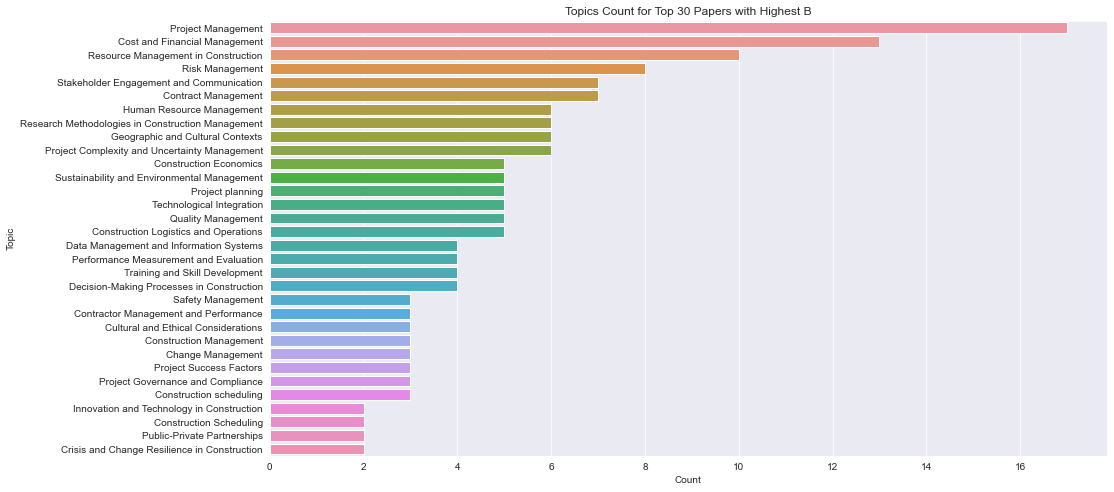

In [34]:
# broad topics
plot_topics_count(df_topic_counts, 'Topics Count for Top 30 Papers with Highest B')

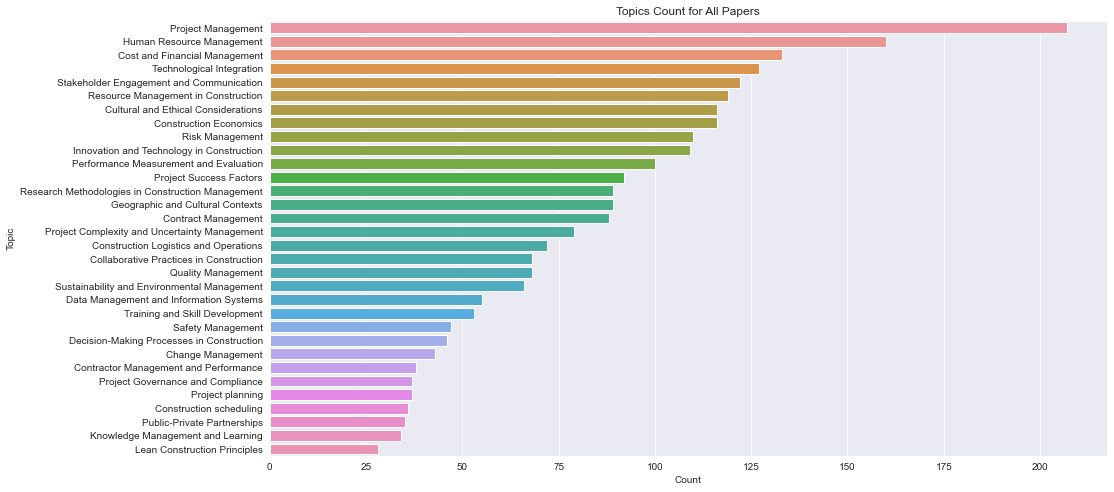

In [54]:
# broad_topics
# all papers
#Count the occurrences of each broad topic in the entire DataFrame
df_topic_counts_all = count_summarized_topics(df)

# Plot the counts of broad topics for all papers
plot_topics_count(df_topic_counts_all, 'Topics Count for All Papers', min_count=25, topics='broad_topics')

In [16]:
# topics
df_topic_counts = count_summarized_topics(top_30_df, topics='topics').drop(index=2)
df_topic_counts

,topics,count
0,Construction industry,7
1,Construction management,7
3,Causes of delay,2
4,Construction productivity,2
5,questionnaire survey,2
...,...,...
271,Complexity factors,1
272,Direct cost,1
273,Indirect cost,1
274,Contingency sum,1


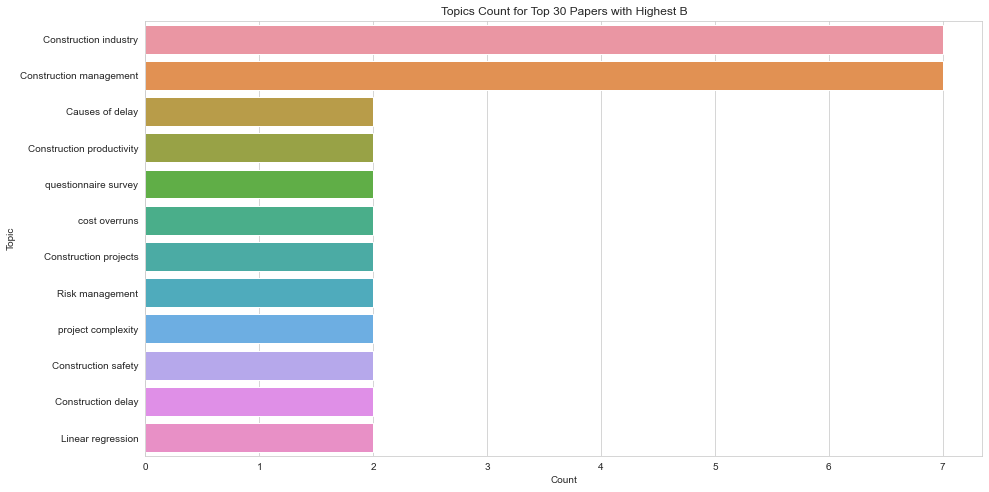

In [20]:
# topics
plot_topics_count(df_topic_counts[df_topic_counts['count'] > 1], 'Topics Count for Top 30 Papers with Highest B', topics='topics')

In [45]:
top_30_df

,Index,File_Name,Paper_Name,Keywords,Journal_Name,Published_Year,Country,Continent,URL,Given Total,...,1984,1983,1982,1981,1980,file_name,topics,broad_topics,Beauty_Coefficient,Awakening_Time
154,206,The characteristics and current status of Chin...,The characteristics and current status of Chin...,"[China, construction industry, economic reform...",Construction Management and Economics,1998.0,United Kingdom,Europe,https://scholar.google.com/scholar?hl=en&as_sd...,1520,...,0.0,0.0,0.0,0.0,0.0,The characteristics and current status of Chin...,"[China, construction industry, economic reform...","[Construction Economics, Sustainability and En...",436.261611,4.0
82,107,1-s2.0-S187770581733179X-main,Potentials of Blockchain Technology for Constr...,"[blockchain, building information modelling, b...",Procedia engineering,2017.0,Slovenia,Europe,https://scholar.google.com/scholar?hl=en&as_sd...,453,...,0.0,0.0,0.0,0.0,0.0,1-s2.0-S187770581733179X-main,"[Blockchain, Construction management, Building...","[Technological Integration, Project Management...",214.183529,1.0
222,297,Strategies for successful construction and dem...,Strategies for successful construction and dem...,"[Recycling, landfill, machinery, demolition, w...",Construction Management and Economics,1997.0,United States,North America,https://scholar.google.com/scholar?hl=en&as_sd...,NaN,...,0.0,0.0,0.0,0.0,0.0,Strategies for successful construction and dem...,"[Construction and demolition waste, Recycling ...","[Sustainability and Environmental Management, ...",170.107359,16.0
28,43,Factors influencing construction time and cost...,Factors influencing construction time and cost...,"[Delays, cost overruns, productivity, high-ris...",Construction management and economics,1997.0,Indonesia,Asia,https://scholar.google.com/scholar?hl=en&as_sd...,1173,...,0.0,0.0,0.0,0.0,0.0,Factors influencing construction time and cost...,"[construction time, cost overruns, high-rise p...","[Project Management, Cost and Financial Manage...",169.686061,11.0
441,585,Important causes of delay in public utility pr...,Important causes of delay in public utility pr...,"[Claims, delay, utility projects, time, Saudi ...",Construction Management and Economics,1999.0,Saudi Arabia,Asia,https://scholar.google.com/scholar?hl=en&as_sd...,336,...,0.0,0.0,0.0,0.0,0.0,Important causes of delay in public utility pr...,"[Delay causes, Public utility projects, Constr...","[Project Management, Public-Private Partnershi...",168.000000,0.0
119,150,A survey of constraints on Iranian constructio...,A survey of constraints on Iranian constructio...,"[Productivity, site operations, Iran.]",Construction Management & Economics,1996.0,United Kingdom,Europe,https://scholar.google.com/scholar?hl=en&as_sd...,219,...,0.0,0.0,0.0,0.0,0.0,A survey of constraints on Iranian constructio...,"[Construction productivity, Iranian constructi...","[Project Management, Human Resource Management...",166.051905,13.0
4,6,1-s2.0-S026378639800060X-main,Construction delay: a quantitative analysis,[Construction management; Project planning; Co...,International Journal of Project Management,2000.0,Jordan,Asia,https://scholar.google.com/scholar?hl=en&as_sd...,936,...,0.0,0.0,0.0,0.0,0.0,1-s2.0-S026378639800060X-main,"[Construction delay, Construction management, ...","[Construction scheduling, Project Management, ...",160.832738,5.0
243,329,Construction safety training using immersive v...,Construction safety training using immersive v...,"[Construction safety, immersive virtual realit...",Construction management and economics,2013.0,Israel,Asia,https://scholar.google.com/scholar?hl=en&as_sd...,641,...,0.0,0.0,0.0,0.0,0.0,Construction safety training using immersive v...,"[Construction safety, Immersive virtual realit...","[Safety Management, Technological Integration,...",139.918349,3.0
425,563,ar2002-099-108_Jackson,PROJECT COST OVERRUNS AND RISK MANAGEMENT,"[design change, design information, cost overr...",Proceedings of Association of Resear

In [23]:
top_30_df['Keywords'] = top_30_df[top_30_df['Keywords'] != -1]['Keywords'].apply(lambda x: [phrase.strip() for phrase in x.split(',')])

df_keywords_counts = count_summarized_topics(top_30_df, 'Keywords')
df_keywords_counts
# count is too sprase so doesn't make sense to plot it

,Keywords,count
0,China,2
1,time,2
2,productivity,2
3,Claims,2
4,Australia,2
...,...,...
111,cost overrun,1
112,design information,1
113,design change,1
114,safety training.,1


Wordcloud for Broad Topics, Topics, and Keywords

In [51]:
# wordcloud
# Function to preprocess topics by replacing spaces with underscores in phrases
def preprocess_topics(topics_list):
    preprocessed_list = []
    for phrase in topics_list:
        # Replace spaces with underscores to keep phrases together
        phrase_with_underscore = "_".join(phrase.split())
        preprocessed_list.append(phrase_with_underscore)
    return preprocessed_list
from wordcloud import WordCloud, STOPWORDS
# Add any additional stopwords you want to exclude
stopwords = set(STOPWORDS)
stopwords.update(["construction", "management", "construction industry", "Project_Management"])  # Let's say you don't want these two phrases to appear


broad_topics

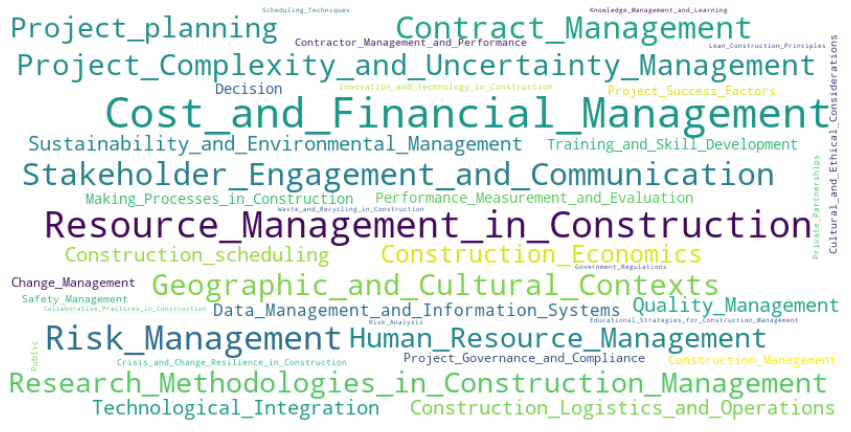

In [25]:
# top30
# Filter the DataFrame
filtered_df = top_30_df

# Preprocess all topics
preprocessed_data = [preprocess_topics(topics) for topics in filtered_df['broad_topics']]

# Flatten the list of preprocessed topics
flat_list = [item for sublist in preprocessed_data for item in sublist]

# Join all topics to form a text that will be used for word cloud
text = " ".join(flat_list)

# Generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False, stopwords=stopwords).generate(text)

# Display the generated image
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

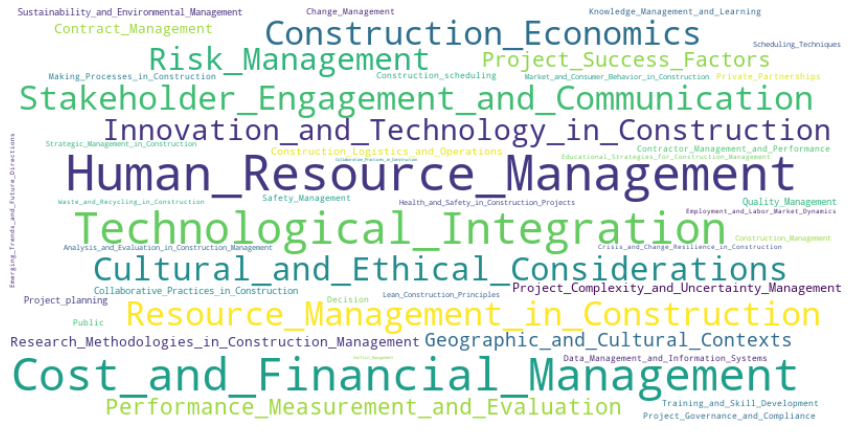

In [52]:
# Filter the DataFrame
# all papers
filtered_df = df

# Preprocess all topics
preprocessed_data = [preprocess_topics(topics) for topics in filtered_df['broad_topics']]

# Flatten the list of preprocessed topics
flat_list = [item for sublist in preprocessed_data for item in sublist]

# Join all topics to form a text that will be used for word cloud
text = " ".join(flat_list)

# Generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False, stopwords=stopwords).generate(text)

# Display the generated image
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

topics

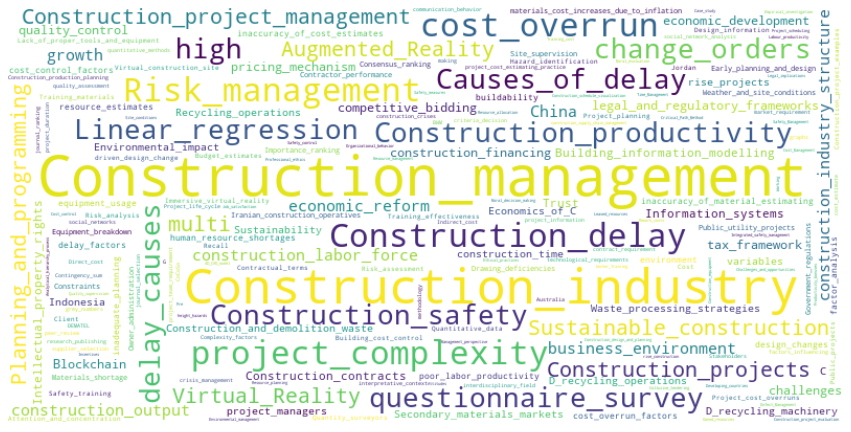

In [26]:
# Filter the DataFrame
filtered_df = top_30_df

# Preprocess all topics
preprocessed_data = [preprocess_topics(topics) for topics in filtered_df['topics']]

# Flatten the list of preprocessed topics
flat_list = [item for sublist in preprocessed_data for item in sublist]

# Join all topics to form a text that will be used for word cloud
text = " ".join(flat_list)

# Generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False, stopwords=stopwords).generate(text)

# Display the generated image
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

keywords

/var/folders/t8/y0j5x77s7zqfzbzs7dpj9c1h0000gn/T/ipykernel_1538/2613547924.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_df = top_30_df[df['Keywords'] != -1]


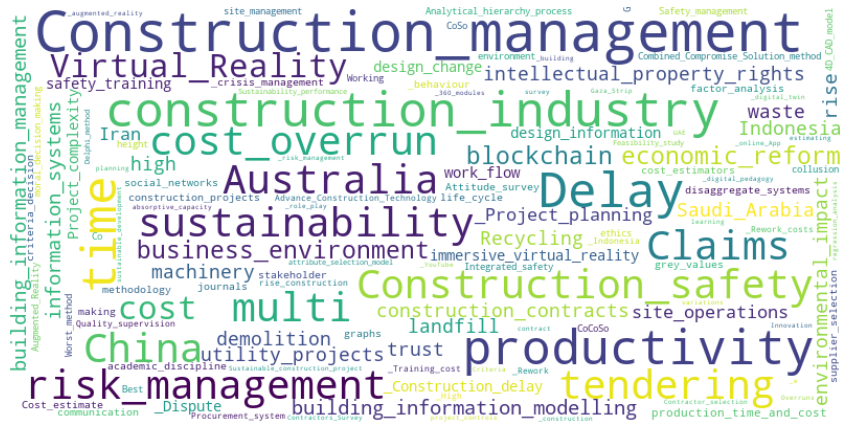

In [28]:
# Filter the DataFrame
filtered_df = top_30_df[df['Keywords'] != -1]

# Preprocess all topics
preprocessed_data = [preprocess_topics(topics) for topics in filtered_df['Keywords']]

# Flatten the list of preprocessed topics
flat_list = [item for sublist in preprocessed_data for item in sublist]

# Join all topics to form a text that will be used for word cloud
text = " ".join(flat_list)

# Generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False, stopwords=stopwords).generate(text)

# Display the generated image
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

# 3. Keywords vs. Topics

# 3. Citation Prediction according to keywords and topics?

Predictive Modeling:

1. Build time series regression models to predict Given Total citations based on:
Publication year
Number of keywords
Specific topics or broad topics
Geographical location
Yearly citations

2. Model Evaluation:
Use metrics like R-squared and RMSE to assess model performance.
Perform cross-validation for robustness.